### https://www.kaggle.com/competitions/drawing-with-llms

In [67]:
import kagglehub
import pandas as pd
import re

train_path = kagglehub.competition_download('drawing-with-llms', 'train.csv')
train = pd.read_csv(train_path)

train.head(2)

,id,description
0,04c411,a starlit night over snow-covered peaks
1,215136,black and white checkered pants


In [7]:
import openai
import pandas as pd
import time
import os
from dotenv import load_dotenv
load_dotenv()
openai_api_key = os.getenv("OPENAI_API_KEY")

In [35]:
# Set up OpenAI client with your API key
client = openai.OpenAI(api_key=openai_api_key)

# Function to get summary from OpenAI API
def get_topic():
    instruction = f"""
    I am participating SVG code generation competition. 
    
    The competition test data comprises about 500 descriptions of everyday objects and scenes from a variety of domains. Your goal is to create a model that generates SVG depictions of these descriptions.
    The descriptions have the following properties:
    The descriptions are of common, generic subjects. No brand name or trademark or personal name occurs in any description. No people, even in generic form, occur in any description.
    The subjects described span about a dozen categories.  The remaining categories in the public and private sets are unique to each set. 
    No description has more than 200 characters. The average length is around 50 characters.   

   
    I am planing to generate syntetic data for my small LLM training. can you please give me 20 topics relavant to the competion above? 
    Each topic should have varying charater from 10 to 200 with 50 charater as average. Half of the topics should be from landscapes, abstract, and fashion.

    Please give your respose in csv format.
    """

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "Generate a topic"},
                {"role": "user", "content": instruction}
            ],
            temperature=0.7,
            max_tokens=12000
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error: {e}")
        return None


In [51]:
# Function to get summary from OpenAI API
def get_svg_code(text):
    instruction = f"""
            Generate SVG code to visually represent the following text description, while respecting the given constraints.
            <constraints>
            * **Allowed Elements:** `svg`, `path`, `circle`, `rect`, `ellipse`, `line`, `polyline`, `polygon`, `g`, `linearGradient`, `radialGradient`, `stop`, `defs`
            * **Allowed Attributes:** `viewBox`, `width`, `height`, `fill`, `stroke`, `stroke-width`, `d`, `cx`, `cy`, `r`, `x`, `y`, `rx`, `ry`, `x1`, `y1`, `x2`, `y2`, `points`, `transform`, `opacity`
            </constraints>

            Please ensure that the generated SVG code is well-formed, valid, and strictly adheres to these constraints. 
            Focus on a clear and concise representation of the input description within the given limitations. 
            Always give the complete SVG code with nothing omitted. Never use an ellipsis.

            input description: {text}
            """

    try:
        response = client.chat.completions.create(
            model="gpt-4o",
            messages=[
                {"role": "system", "content": "Generate SVG code as per instruction"},
                {"role": "user", "content": instruction}
            ],
            temperature=0.2,
            max_tokens=1024
        )
        return response.choices[0].message.content.strip()
    
    except Exception as e:
        print(f"Error: {e}")
        return None

In [59]:
# #generate random topic for svg training date
# topics_list=[]
# for i in range(20):

#     response=get_topic()

#     print('##### Response ##########')
#     print(response)
#     print('\n')
    
#     # Extracting topics using regex
#     topics = re.findall(r'"(.*?)"', response)
#     # Removing the header "Topic"
#     topics = [t for t in topics if t.lower() != "topic"]
#     topics_list.extend(topics)
      
#     print(topics)

In [52]:
import pandas as pd
df = pd.read_table("topics_1.txt", header=None)
df.columns = ["topic"]

In [56]:
from tqdm import tqdm
tqdm.pandas() 
df["response"] = df["topic"].progress_apply(get_svg_code)

100%|█████████████████████████████████████████| 602/602 [43:38<00:00,  4.35s/it]


In [58]:
df.to_csv('response.csv',index=False)

In [61]:
def clean_svg(text):
    svg_code = re.search(r'```svg\n(.*?)\n```', text, re.DOTALL)
    
    if svg_code:
        extracted_svg = svg_code.group(1)
        return extracted_svg
    else:
        return '<svg </svg>'

In [62]:
df["svg_code"] = df["response"].progress_apply(clean_svg)

100%|█████████████████████████████████████| 602/602 [00:00<00:00, 116481.57it/s]


In [63]:
df

,topic,svg_code,response
0,"'Golden wheat fields under a setting sun',","<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""..."
1,'Vibrant orange circles on a cobalt blue back...,"<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""..."
2,"'Emerald silk dress with silver embroidery',","<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""..."
3,"'Snowy mountains under a clear blue sky',","<svg viewBox=""0 0 200 100"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 100"" width=""200""..."
4,'Checkerboard pattern with alternating green ...,"<svg viewBox=""0 0 100 100"" width=""100"" height=...","```svg\n<svg viewBox=""0 0 100 100"" width=""100""..."
...,...,...,...
597,'Scarlet and white polka dots on a navy backd...,"<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""..."
598,"'Intricate mosaic of teal and coral tiles',","<svg viewBox=""0 0 100 100"" width=""100"" height=...","```svg\n<svg viewBox=""0 0 100 100"" width=""100""..."
599,"'Amber and burgundy plaid pattern',","<svg viewBox=""0 0 100 100"" width=""100"" height=...","```svg\n<svg viewBox=""0 0 100 100"" width=""100""..."
600,"'Rolling hills under a misty dawn',","<svg viewBox=""0 0 200 100"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 100"" width=""200""..."


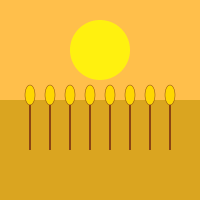

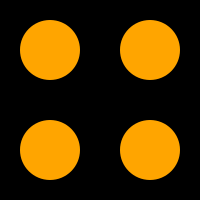

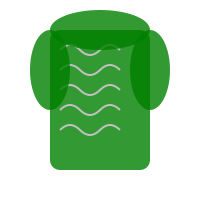

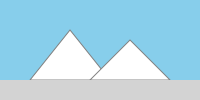

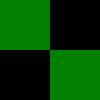

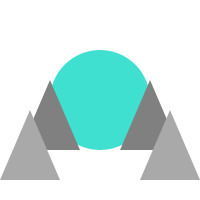

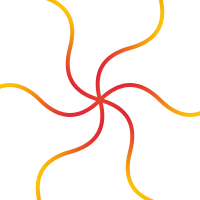

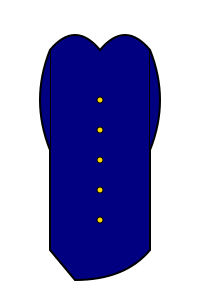

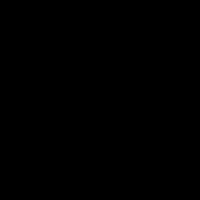

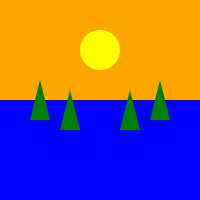

In [64]:
# We can play with our Model and render its SVG output (don't export!)
from IPython.display import SVG, display
for svg in df["svg_code"].iloc[:10]:
    #print(svg)
    display(SVG(svg))

In [65]:
from transformers import AutoProcessor, AutoModel
model = AutoModel.from_pretrained("google/siglip-so400m-patch14-384")
processor = AutoProcessor.from_pretrained("google/siglip-so400m-patch14-384")

In [66]:
import torch
from PIL import Image
import cairosvg
import os

def svgMetric(prompt, svg):
    try:
        # Convert SVG to PNG
        cairosvg.svg2png(svg, write_to="./tmp/temp.png")
        
        # Open and process the image
        image = Image.open('./tmp/temp.png').convert("RGB")
        texts = ["SVG illustration of " + prompt]
        inputs = processor(text=texts, images=image, padding="max_length", return_tensors="pt")
        
        # Inference without gradient tracking
        with torch.no_grad():
            outputs = model(**inputs)
        
        logits_per_image = outputs.logits_per_image
        probs = torch.sigmoid(logits_per_image)
        
        # Clean up temporary PNG file
        #os.remove('./tmp/temp.png')
        
        return probs[0][0].item()

    
    except Exception as e:
        print(f"An error occurred: {e}")
        return None




In [69]:
# Using apply to process each row in the DataFrame
df['score'] = df.progress_apply(lambda row: svgMetric(row['topic'], row['svg_code']), axis=1)


100%|█████████████████████████████████████████| 602/602 [15:13<00:00,  1.52s/it]


In [71]:
# Display results
print('mean gpt-4o score:',df['score'].mean())

mean gpt-4o score: 0.5458038481761948


In [70]:
df.to_csv('svg_score.csv',index=False)

In [72]:
df

,topic,svg_code,response,score
0,"'Golden wheat fields under a setting sun',","<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""...",0.994973
1,'Vibrant orange circles on a cobalt blue back...,"<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""...",0.050704
2,"'Emerald silk dress with silver embroidery',","<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""...",0.000404
3,"'Snowy mountains under a clear blue sky',","<svg viewBox=""0 0 200 100"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 100"" width=""200""...",0.978844
4,'Checkerboard pattern with alternating green ...,"<svg viewBox=""0 0 100 100"" width=""100"" height=...","```svg\n<svg viewBox=""0 0 100 100"" width=""100""...",0.998181
...,...,...,...,...
597,'Scarlet and white polka dots on a navy backd...,"<svg viewBox=""0 0 200 200"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 200"" width=""200""...",0.218353
598,"'Intricate mosaic of teal and coral tiles',","<svg viewBox=""0 0 100 100"" width=""100"" height=...","```svg\n<svg viewBox=""0 0 100 100"" width=""100""...",0.448915
599,"'Amber and burgundy plaid pattern',","<svg viewBox=""0 0 100 100"" width=""100"" height=...","```svg\n<svg viewBox=""0 0 100 100"" width=""100""...",0.740879
600,"'Rolling hills under a misty dawn',","<svg viewBox=""0 0 200 100"" width=""200"" height=...","```svg\n<svg viewBox=""0 0 200 100"" width=""200""...",0.991852


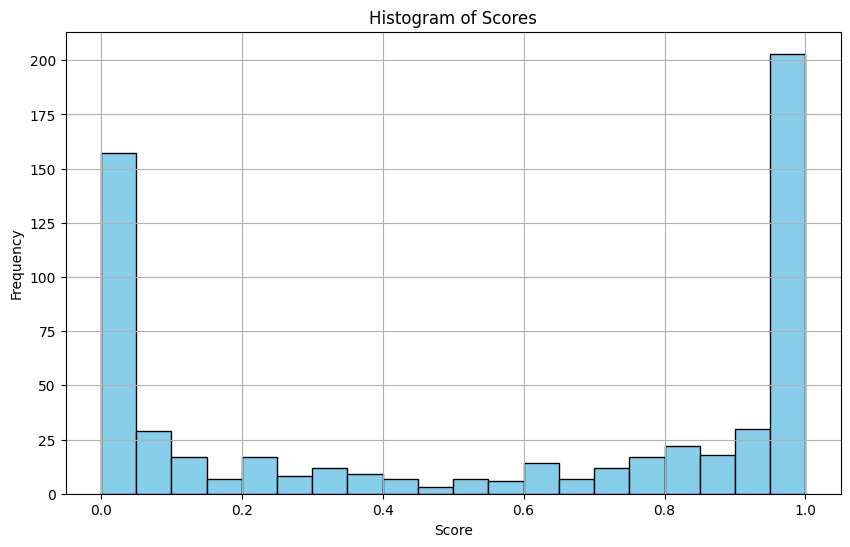

In [75]:
import matplotlib.pyplot as plt

# Plot histogram of the 'score' column
plt.figure(figsize=(10, 6))
plt.hist(df['score'], bins=20, color='skyblue', edgecolor='black')
plt.title('Histogram of Scores')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()